In [1]:
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import os

from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from scipy.spatial.distance import cdist

from aero_optim.mf_sm.mf_infill import compute_pareto

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Times",
    "figure.dpi": 300,
    "font.size": 8,
    'legend.fontsize': 8, 
    "axes.titlesize": 8,
    "axes.labelsize": 8
})

In [2]:
n_gen = 25
pop_size = 30

Values corresponding to the mixed-out loss experiments (AIFLUID)

In [3]:
# LES mixed-out loss
bsl_w_ADP = 0.0349
bsl_w_OP = 0.0483

# non-adapted fine mesh mixed-out loss
lf_bsl_w_ADP = 0.0749
lf_bsl_w_OP = 0.125

baseline_file = "ogv1c.dat"
baseline = np.loadtxt(baseline_file, skiprows=2) * 1e-3

In [4]:
def get_cand_fit(outdir: str) -> tuple[np.ndarray]:
    return np.loadtxt(os.path.join(outdir, "candidates.txt")), np.loadtxt(os.path.join(outdir, "fitnesses.txt"))

def get_best_candidates_idx(fitnesses: np.ndarray, pareto_set: np.ndarray, nb_comp: int = 1) -> tuple[int, int, list[int]]:
    # best ADP
    ADP_cand_idx = np.where(fitnesses[:, 0] == np.min(pareto_set[:, 0]))[0][0]
    print(f"best ADP candidates {ADP_cand_idx}: {fitnesses[ADP_cand_idx]}")
    print(f"best candidate from gen {ADP_cand_idx // pop_size} cand {ADP_cand_idx % pop_size}\n")
    # best OP
    OP_cand_idx = np.where(fitnesses[:, 1] == np.min(pareto_set[:, 1]))[0][0]
    print(f"best OP candidates {OP_cand_idx}: {fitnesses[OP_cand_idx]}")
    print(f"best candidate from gen {OP_cand_idx // pop_size} cand {OP_cand_idx % pop_size}\n")
    # best compromise
    # matrix made of the distance between each point in the ordered pareto front
    d_matrix = np.linalg.norm(pareto_set[:, np.newaxis] - pareto_set[np.newaxis, :], axis=-1)
    # 1d array with the distance between two consecutive points along the ordered pareto front
    s = np.array([d_matrix[i + 1, i] for i in range(len(d_matrix) - 1)])
    s_length = np.sum(s)
    # index of the closest point to the pareto set center
    cand_idx = []
    for cid in range(nb_comp):
        idx = np.argmin([abs(np.sum(s[:i]) - (cid + 1) * s_length / (nb_comp + 1)) for i in range(len(s))])
        cand_idx.append(np.where(fitnesses == pareto_set[idx])[0][0])
        print(f"best compromise candidates {cand_idx[-1]}: {fitnesses[cand_idx[-1]]}")
        print(f"best candidate from gen {cand_idx[-1] // pop_size} cand {cand_idx[-1] % pop_size}\n")
    return ADP_cand_idx, OP_cand_idx, cand_idx

def get_closest_candidate_idx(fitnesses: np.ndarray, pareto_set: np.ndarray, target_fit: float) -> int:
    dist_to_fit = cdist(pareto_set, target_fit, "euclidean")
    idx = np.argmin(dist_to_fit)
    return np.where(fitnesses[:, 0] == pareto_set[idx, 0])[0][0]


def get_profile(outdir: str, idx: int) -> np.ndarray:
    return np.loadtxt(os.path.join(outdir, "FFD", f"ogv1c_g{idx // pop_size}_c{idx % pop_size}.dat"), skiprows=2)

def get_DOE(model_file: str) -> tuple[np.ndarray]:
    with open(model_file, "rb") as handle:
        model = pickle.load(handle)

    try:
        x_lf = model.models[0].x_lf_DOE
        x_hf = model.models[0].x_hf_DOE
        y_lf = np.column_stack([model.models[0].y_lf_DOE, model.models[1].y_lf_DOE])
        y_hf = np.column_stack([model.models[0].y_hf_DOE, model.models[1].y_hf_DOE])
    except AttributeError:
        x_lf = model.x_lf_DOE
        x_hf = model.x_hf_DOE
        y_lf = model.y_lf_DOE
        y_hf = model.y_hf_DOE
    return x_lf, x_hf, y_lf, y_hf

In [8]:
# mixed-out loss results
lf_dir = "output"
lf_cand, lf_fit = get_cand_fit(lf_dir)
lf_pareto = compute_pareto(lf_fit[:, 0], lf_fit[:, 1])

In [9]:
lf_pareto_idx = [np.where(lf_fit == pid)[0][0] for pid in lf_pareto]
for idx in lf_pareto_idx:
    print(f"idx {idx} gen {idx // pop_size}, cand {idx % pop_size}: {lf_fit[idx]}")

idx 13 gen 0, cand 13: [0.04927429 0.14207037]
idx 30 gen 1, cand 0: [0.05144167 0.13901723]
idx 467 gen 15, cand 17: [0.05228647 0.12814759]
idx 184 gen 6, cand 4: [0.05639063 0.127689  ]
idx 319 gen 10, cand 19: [0.05645711 0.10327194]
idx 318 gen 10, cand 18: [0.05677018 0.10322158]
idx 200 gen 6, cand 20: [0.05731763 0.08961518]
idx 504 gen 16, cand 24: [0.08249887 0.08613325]
idx 333 gen 11, cand 3: [0.08462715 0.08574326]
idx 627 gen 20, cand 27: [0.08555802 0.08471551]
idx 583 gen 19, cand 13: [0.08657271 0.08398663]


In [10]:
lf_ADP_cand_idx, lf_OP_cand_idx, lf_cand_idx = get_best_candidates_idx(lf_fit, lf_pareto, 2)

lf_ADP_target = lf_fit[lf_ADP_cand_idx, :]
lf_OP_target = lf_fit[lf_OP_cand_idx, :]
lf_comp_target = lf_fit[lf_cand_idx, :]

lf_opt = np.vstack([lf_ADP_target, lf_OP_target, lf_comp_target])

# np.savetxt("lf_fitnesses.txt", lf_opt)

best ADP candidates 13: [0.04927429 0.14207037]
best candidate from gen 0 cand 13

best OP candidates 583: [0.08657271 0.08398663]
best candidate from gen 19 cand 13

best compromise candidates 184: [0.05639063 0.127689  ]
best candidate from gen 6 cand 4

best compromise candidates 200: [0.05731763 0.08961518]
best candidate from gen 6 cand 20



In [11]:
lf_opt_cand = [get_profile("output", idx) * 1e-3 for idx in [lf_ADP_cand_idx, lf_OP_cand_idx] + lf_cand_idx]

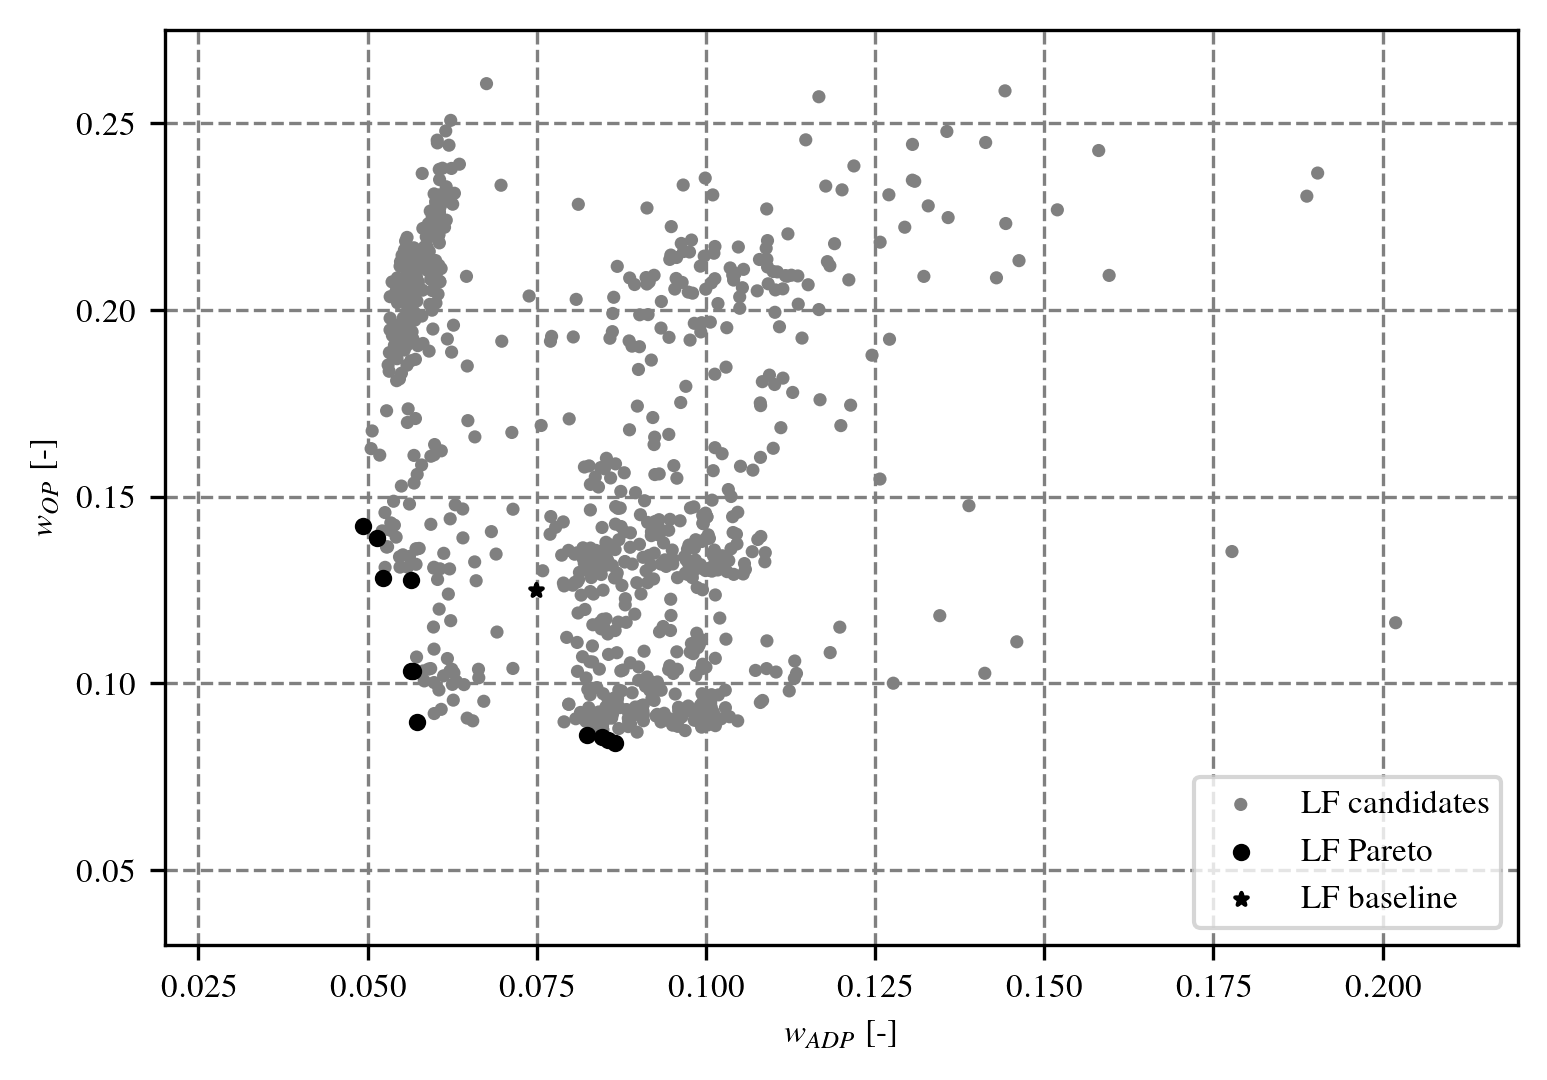

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))
# plotting data: last gen. pareto, y_hf infill, hf baseline
ax.scatter(lf_fit[:, 0], lf_fit[:, 1], marker="o", s=10, color="gray", edgecolors="none", label="LF candidates", zorder=-1)
ax.scatter(lf_pareto[:, 0], lf_pareto[:, 1], marker="o", s=10, color="k", label="LF Pareto")
ax.scatter(lf_bsl_w_ADP, lf_bsl_w_OP, marker="*", s=10, color="k", label="LF baseline")
ax.plot()
ax.set_axisbelow(True)
plt.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.030, 0.275)
ax.set_xlim(0.020, 0.220)
# legend and title
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "lf_pareto_opt_1.pdf"), bbox_inches="tight")
plt.show()

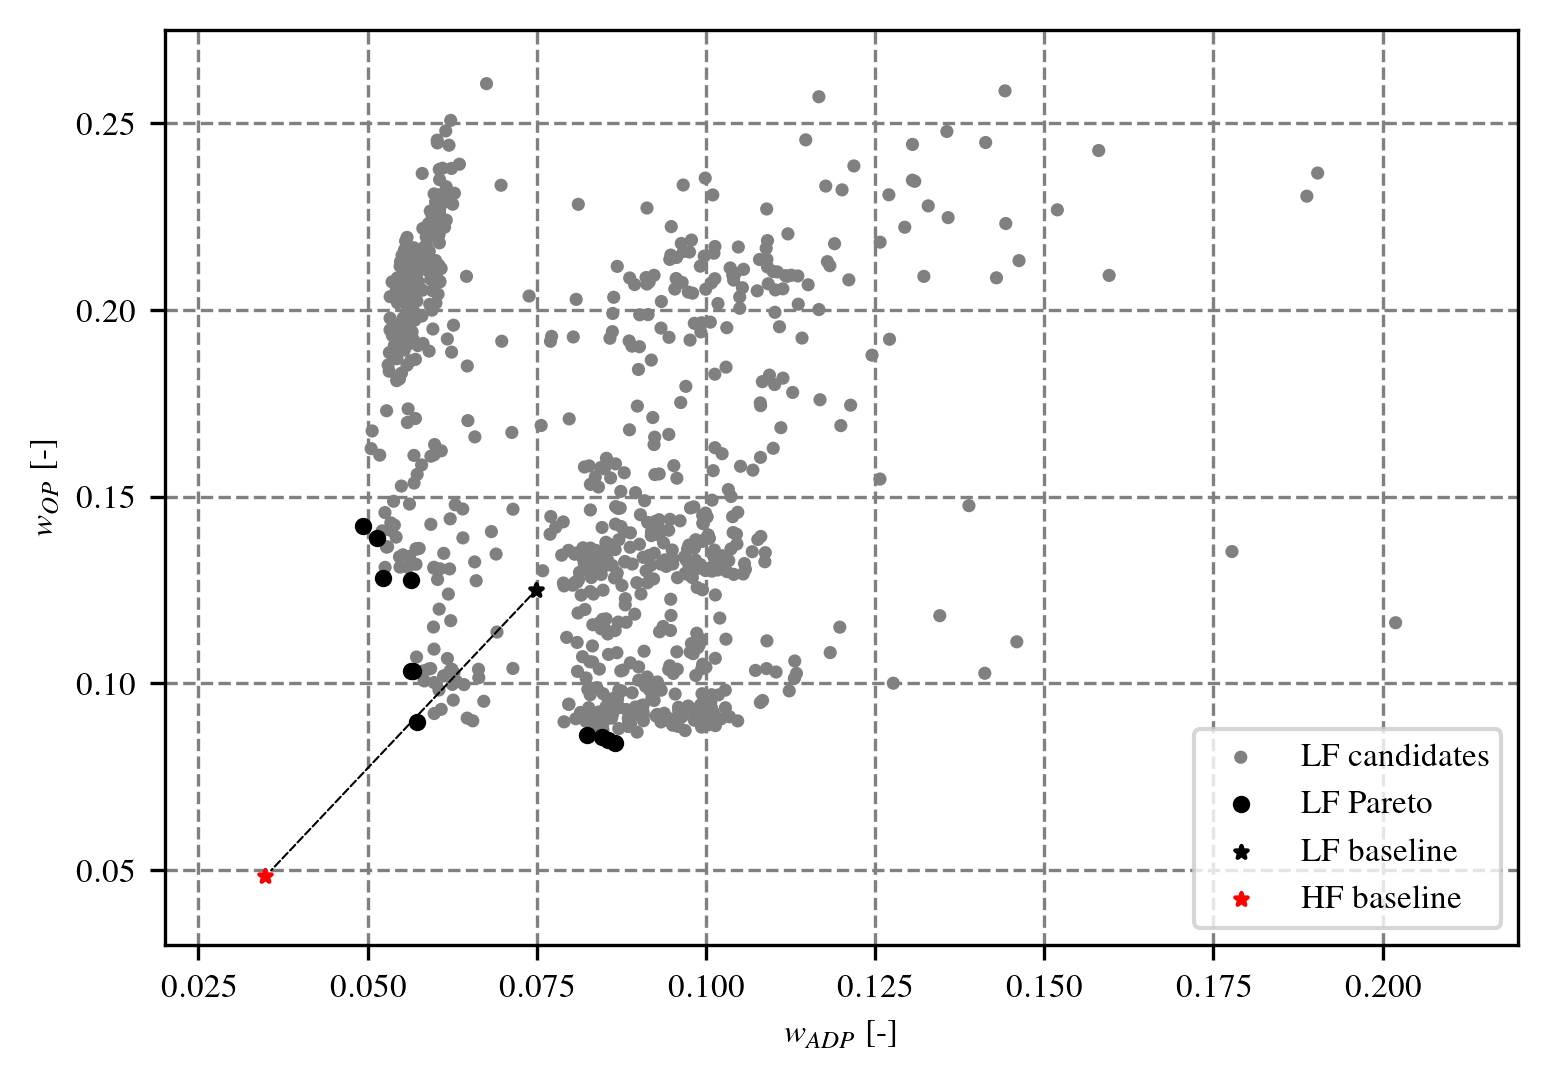

In [13]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))
# candidates and Pareto
ax.scatter(lf_fit[:, 0], lf_fit[:, 1], marker="o", s=10, color="gray", edgecolors="none", label="LF candidates", zorder=-1)
ax.scatter(lf_pareto[:, 0], lf_pareto[:, 1], marker="o", s=10, color="k", label="LF Pareto")
# baseline
ax.scatter(lf_bsl_w_ADP, lf_bsl_w_OP, marker="*", s=10, color="k", label="LF baseline")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", s=10, color="r", label="HF baseline")
ax.annotate('', xy=(bsl_w_ADP, bsl_w_OP), xytext=(lf_bsl_w_ADP, lf_bsl_w_OP), arrowprops=dict(arrowstyle='-', linestyle="--", linewidth=0.5, color='black'))
ax.plot()
ax.set_axisbelow(True)
plt.grid(True, color="grey", linestyle="dashed")
ax.set_ylim(0.03, 0.275)
ax.set_xlim(0.020, 0.220)
# legend and title
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(), "lf_pareto_opt_2.pdf"), bbox_inches="tight")
plt.show()

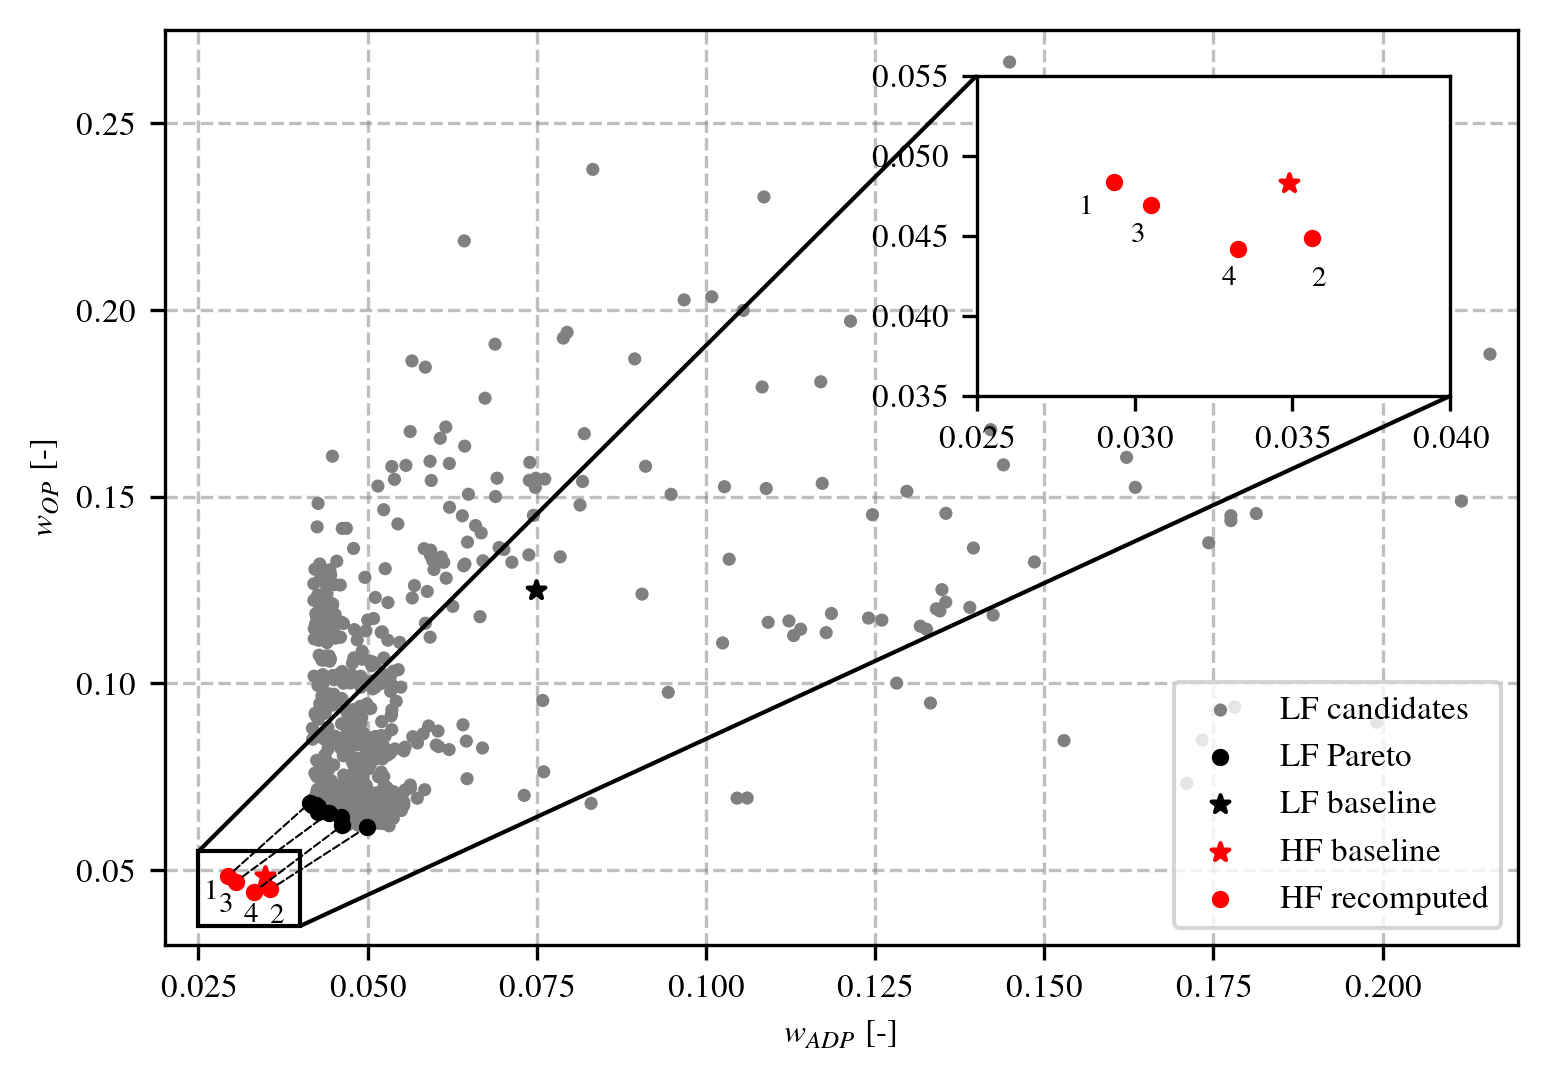

In [12]:
# Pareto recomputed
X_recomp = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_lf_opt/fitnesses.txt")

fig, ax = plt.subplots(figsize=(5.2, 3.64))
# candidates and Pareto
ax.scatter(lf_fit[:, 0], lf_fit[:, 1], marker="o", s=10, color="gray", edgecolors="none", label="LF candidates", zorder=-1)
ax.scatter(lf_pareto[:, 0], lf_pareto[:, 1], marker="o", s=10, color="k", label="LF Pareto")
# baseline
ax.scatter(lf_bsl_w_ADP, lf_bsl_w_OP, marker="*", s=20, color="k", label="LF baseline")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", s=20, color="r", label="HF baseline")
# lf-optimal recomputed DOE
plt.scatter(X_recomp[:, 0], X_recomp[:, 1], marker='o', c="r", s=10, label="HF recomputed")
for ii in range(len(X_recomp)):
    ax.annotate('', xy=(lf_opt[ii, 0], lf_opt[ii, 1]), xytext=(X_recomp[ii, 0], X_recomp[ii, 1]), arrowprops=dict(arrowstyle='-', linestyle="--", linewidth=0.5, color='black'))
# numbers next to point
plt.text(X_recomp[0, 0] - 0.003, X_recomp[0, 1] - 0.006, 1, fontsize=7)
plt.text(X_recomp[1, 0], X_recomp[1, 1] - 0.009, 2, fontsize=7)
plt.text(X_recomp[2, 0] -0.0023, X_recomp[2, 1] - 0.008, 3, fontsize=7)
plt.text(X_recomp[3, 0] -0.0015, X_recomp[3, 1] - 0.008, 4, fontsize=7)
# zoomed area
axins1 = ax.inset_axes([0.60, 0.60, 0.35, 0.35])
axins1.scatter(bsl_w_ADP, bsl_w_OP, marker="*", s=20, color="r", label="HF baseline")
axins1.scatter(X_recomp[:, 0], X_recomp[:, 1], marker='o', c="r", s=10, label="HF recomputed")
# numbers next to text
axins1.text(X_recomp[0, 0] - 0.001, X_recomp[0, 1] - 0.002, 1, fontsize=7)
axins1.text(X_recomp[1, 0], X_recomp[1, 1] - 0.003, 2, fontsize=7)
axins1.text(X_recomp[2, 0] -0.0006, X_recomp[2, 1] - 0.0023, 3, fontsize=7)
axins1.text(X_recomp[3, 0] -0.0005, X_recomp[3, 1] - 0.0023, 4, fontsize=7)
# limits
axins1.set_xlim(0.025, 0.040)
axins1.set_ylim(0.035, 0.055)
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="k")
ax.set_axisbelow(True)
plt.grid(True, color="grey", alpha=0.5, linestyle="dashed")
ax.set_ylim(0.03, 0.275)
ax.set_xlim(0.020, 0.220)
# legend and title
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "lf_pareto_opt.pdf"), bbox_inches="tight")
plt.show()

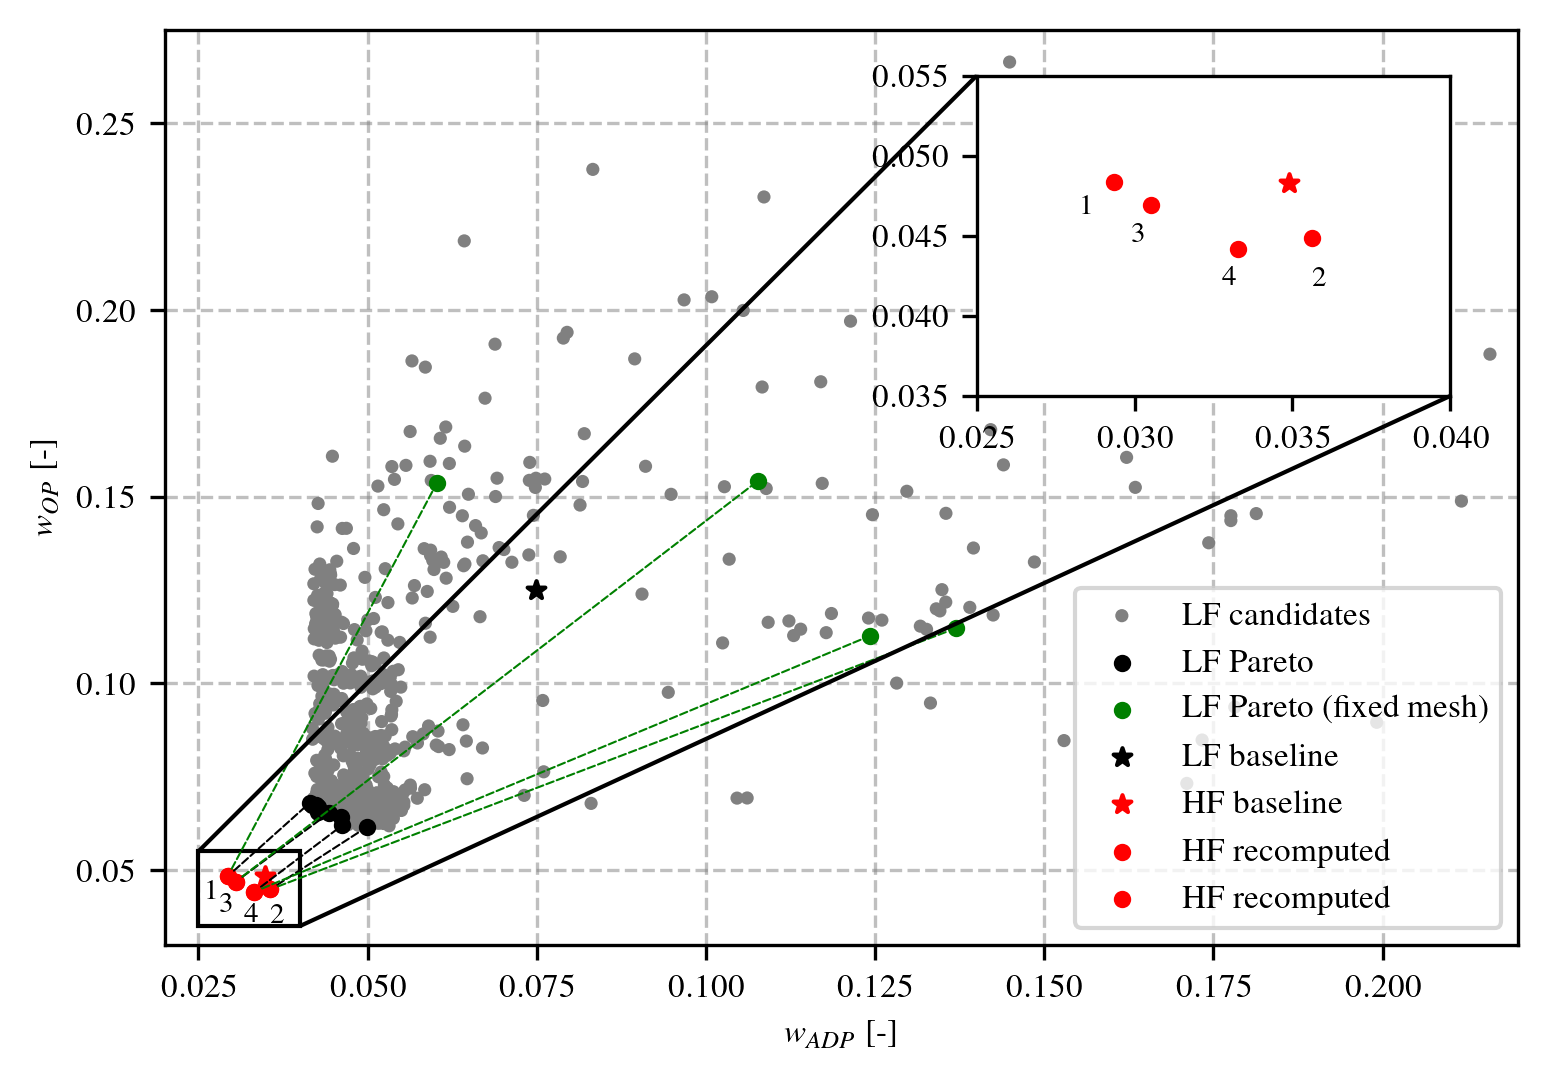

In [14]:
# effect of mesh fix (g39, c10; g25, c18; g32, c18; g39, c3)
lf_opt_fixed = np.array([[0.06024, 0.5 * (0.1654 + 0.1419)],
                         [0.1369, 0.5 * (0.1276 + 0.1019)],
                         [0.1077, 0.5 * (0.1541 + 0.1544)],
                         [0.1242, 0.5 * (0.1244 + 0.1010)]])

fig, ax = plt.subplots(figsize=(5.2, 3.64))
# candidates and Pareto
ax.scatter(lf_fit[:, 0], lf_fit[:, 1], marker="o", s=10, color="gray", edgecolors="none", label="LF candidates", zorder=-1)
ax.scatter(lf_pareto[:, 0], lf_pareto[:, 1], marker="o", s=10, color="k", label="LF Pareto")
ax.scatter(lf_opt_fixed[:, 0], lf_opt_fixed[:, 1], marker="o", s=10, color="g", label="LF Pareto (fixed mesh)")
# baseline
ax.scatter(lf_bsl_w_ADP, lf_bsl_w_OP, marker="*", s=20, color="k", label="LF baseline")
ax.scatter(bsl_w_ADP, bsl_w_OP, marker="*", s=20, color="r", label="HF baseline")
# lf-optimal recomputed DOE
plt.scatter(X_recomp[:, 0], X_recomp[:, 1], marker='o', c="r", s=10, label="HF recomputed")
for ii in range(len(X_recomp)):
    ax.annotate('', xy=(lf_opt[ii, 0], lf_opt[ii, 1]), xytext=(X_recomp[ii, 0], X_recomp[ii, 1]), arrowprops=dict(arrowstyle='-', linestyle="--", linewidth=0.5, color='black'))
# lf-fixed recomputed DOE
plt.scatter(X_recomp[:, 0], X_recomp[:, 1], marker='o', c="r", s=10, label="HF recomputed")
for ii in range(len(X_recomp)):
    ax.annotate('', xy=(lf_opt_fixed[ii, 0], lf_opt_fixed[ii, 1]), xytext=(X_recomp[ii, 0], X_recomp[ii, 1]), arrowprops=dict(arrowstyle='-', linestyle="--", linewidth=0.5, color='g'))
# numbers next to point
plt.text(X_recomp[0, 0] - 0.003, X_recomp[0, 1] - 0.006, 1, fontsize=7)
plt.text(X_recomp[1, 0], X_recomp[1, 1] - 0.009, 2, fontsize=7)
plt.text(X_recomp[2, 0] -0.0023, X_recomp[2, 1] - 0.008, 3, fontsize=7)
plt.text(X_recomp[3, 0] -0.0015, X_recomp[3, 1] - 0.008, 4, fontsize=7)
# zoomed area
axins1 = ax.inset_axes([0.60, 0.60, 0.35, 0.35])
axins1.scatter(bsl_w_ADP, bsl_w_OP, marker="*", s=20, color="r", label="HF baseline")
axins1.scatter(X_recomp[:, 0], X_recomp[:, 1], marker='o', c="r", s=10, label="HF recomputed")
# numbers next to text
axins1.text(X_recomp[0, 0] - 0.001, X_recomp[0, 1] - 0.002, 1, fontsize=7)
axins1.text(X_recomp[1, 0], X_recomp[1, 1] - 0.003, 2, fontsize=7)
axins1.text(X_recomp[2, 0] -0.0006, X_recomp[2, 1] - 0.0023, 3, fontsize=7)
axins1.text(X_recomp[3, 0] -0.0005, X_recomp[3, 1] - 0.0023, 4, fontsize=7)
# limits
axins1.set_xlim(0.025, 0.040)
axins1.set_ylim(0.035, 0.055)
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="k")
ax.set_axisbelow(True)
plt.grid(True, color="grey", alpha=0.5, linestyle="dashed")
ax.set_ylim(0.03, 0.275)
ax.set_xlim(0.020, 0.220)
# legend and title
ax.legend(loc="lower right")
ax.set_xlabel('$w_{ADP}$ [-]')
ax.set_ylabel('$w_{OP}$ [-]')
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "lf_fixed_pareto_opt.pdf"), bbox_inches="tight")
plt.show()

In [15]:
(np.array([bsl_w_ADP, bsl_w_OP]) - X_recomp) / np.array([bsl_w_ADP, bsl_w_OP]) * 100

NameError: name 'X_recomp' is not defined

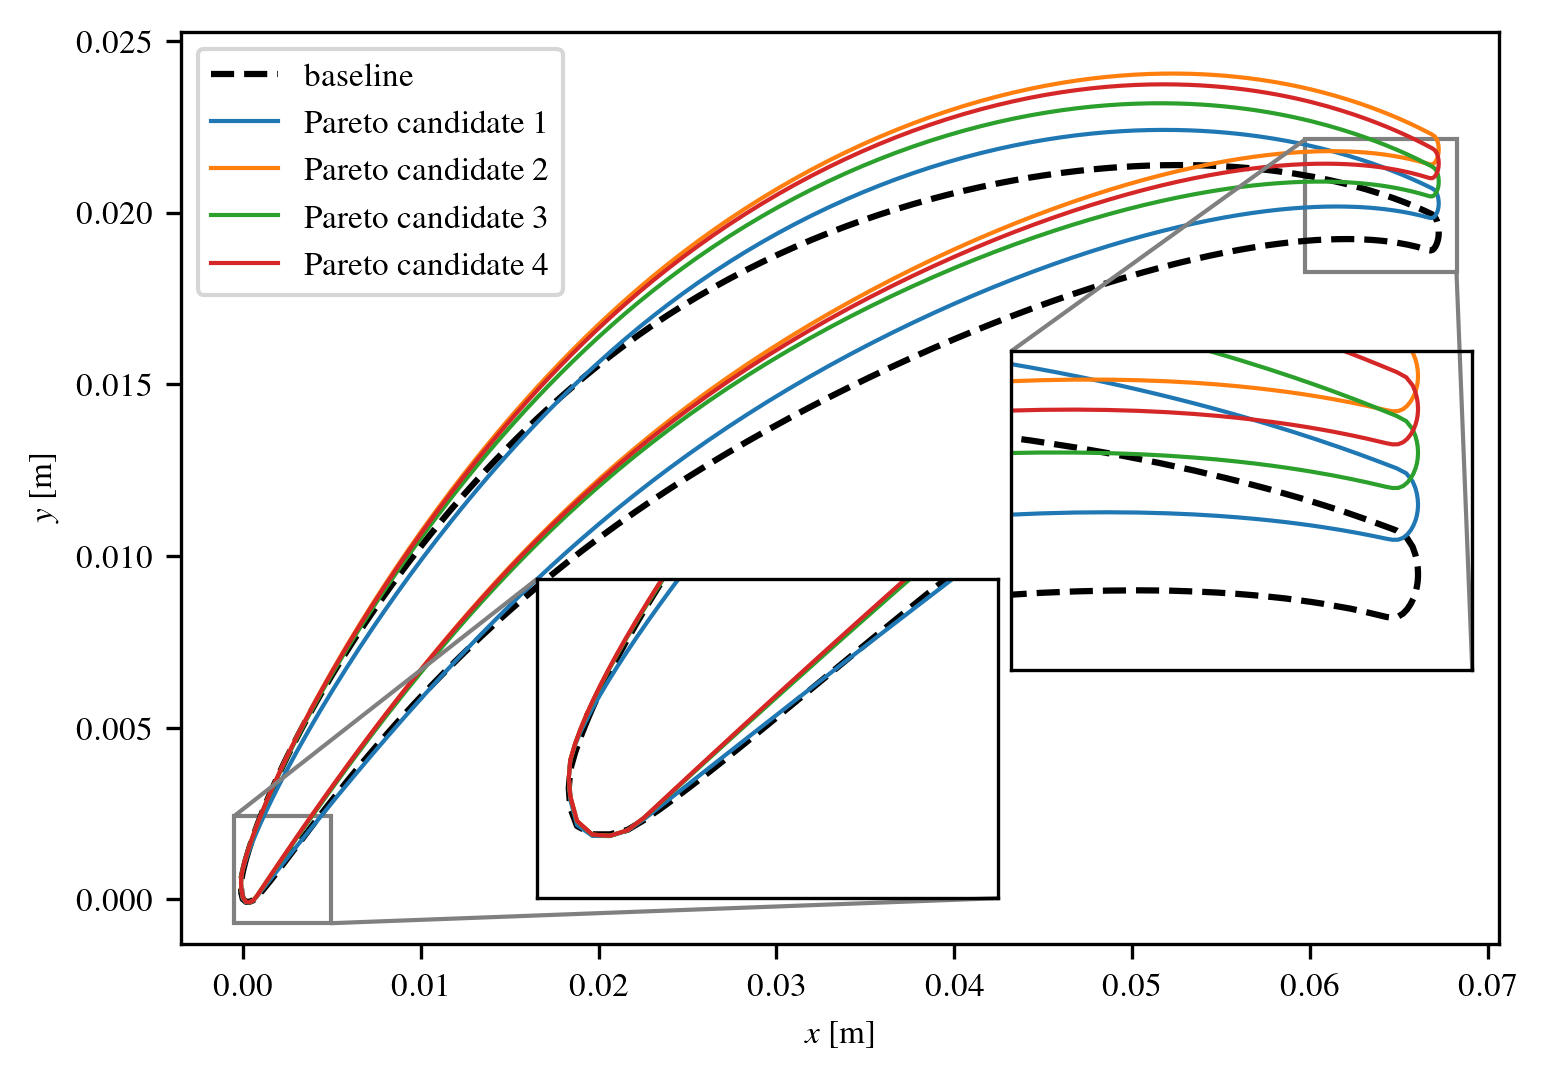

In [16]:
fig, ax = plt.subplots(figsize=(5.2, 3.64))

Delta = 0.0025

# baseline
ax.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed", label="baseline")
for num, pro in enumerate(lf_opt_cand):
    ax.plot(pro[:, 0], pro[:, 1], linewidth=1, label=f"Pareto candidate {num + 1}")
ax.set(xlabel='$x$ [m]', ylabel='$y$ [m]')
ax.legend()

# === Leading Edge Inset ===
# axins1 = inset_axes(ax, width="30%", height="30%", loc="lower center", borderpad=2)
axins1 = ax.inset_axes([0.27, 0.05, 0.35, 0.35])
axins1.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins1.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins1.set_xlim(min(baseline[:, 0]) - 0.15 * Delta, min(baseline[:, 1]) + 2 * Delta)
axins1.set_ylim(min(baseline[:, 1]) - 0.25 * Delta, min(baseline[:, 1]) + Delta)
axins1.set_xticks([])
axins1.set_yticks([])
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="0.5")

# === Trailing Edge Inset ===
# axins2 = inset_axes(ax, width="30%", height="30%", loc="center right", borderpad=2)
axins2 = ax.inset_axes([0.63, 0.3, 0.35, 0.35])
axins2.plot(baseline[:, 0], baseline[:, 1], color="k", linestyle="dashed")
for num, pro in enumerate(lf_opt_cand):
    axins2.plot(pro[:, 0], pro[:, 1], linewidth=1)
axins2.set_xlim(max(baseline[:, 0]) - 3 * Delta, max(baseline[:, 0]) + 0.4 * Delta)
axins2.set_ylim(max(baseline[:, 1]) - 1.25 * Delta, max(baseline[:, 1]) + 0.3 * Delta)
axins2.set_xticks([])
axins2.set_yticks([])
mark_inset(ax, axins2, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), "lf_profile_opt.pdf"), bbox_inches="tight")
plt.show()

Parameters pairplot

In [17]:
data = lf_cand
n_features = data.shape[1]
n_samples = data.shape[0]

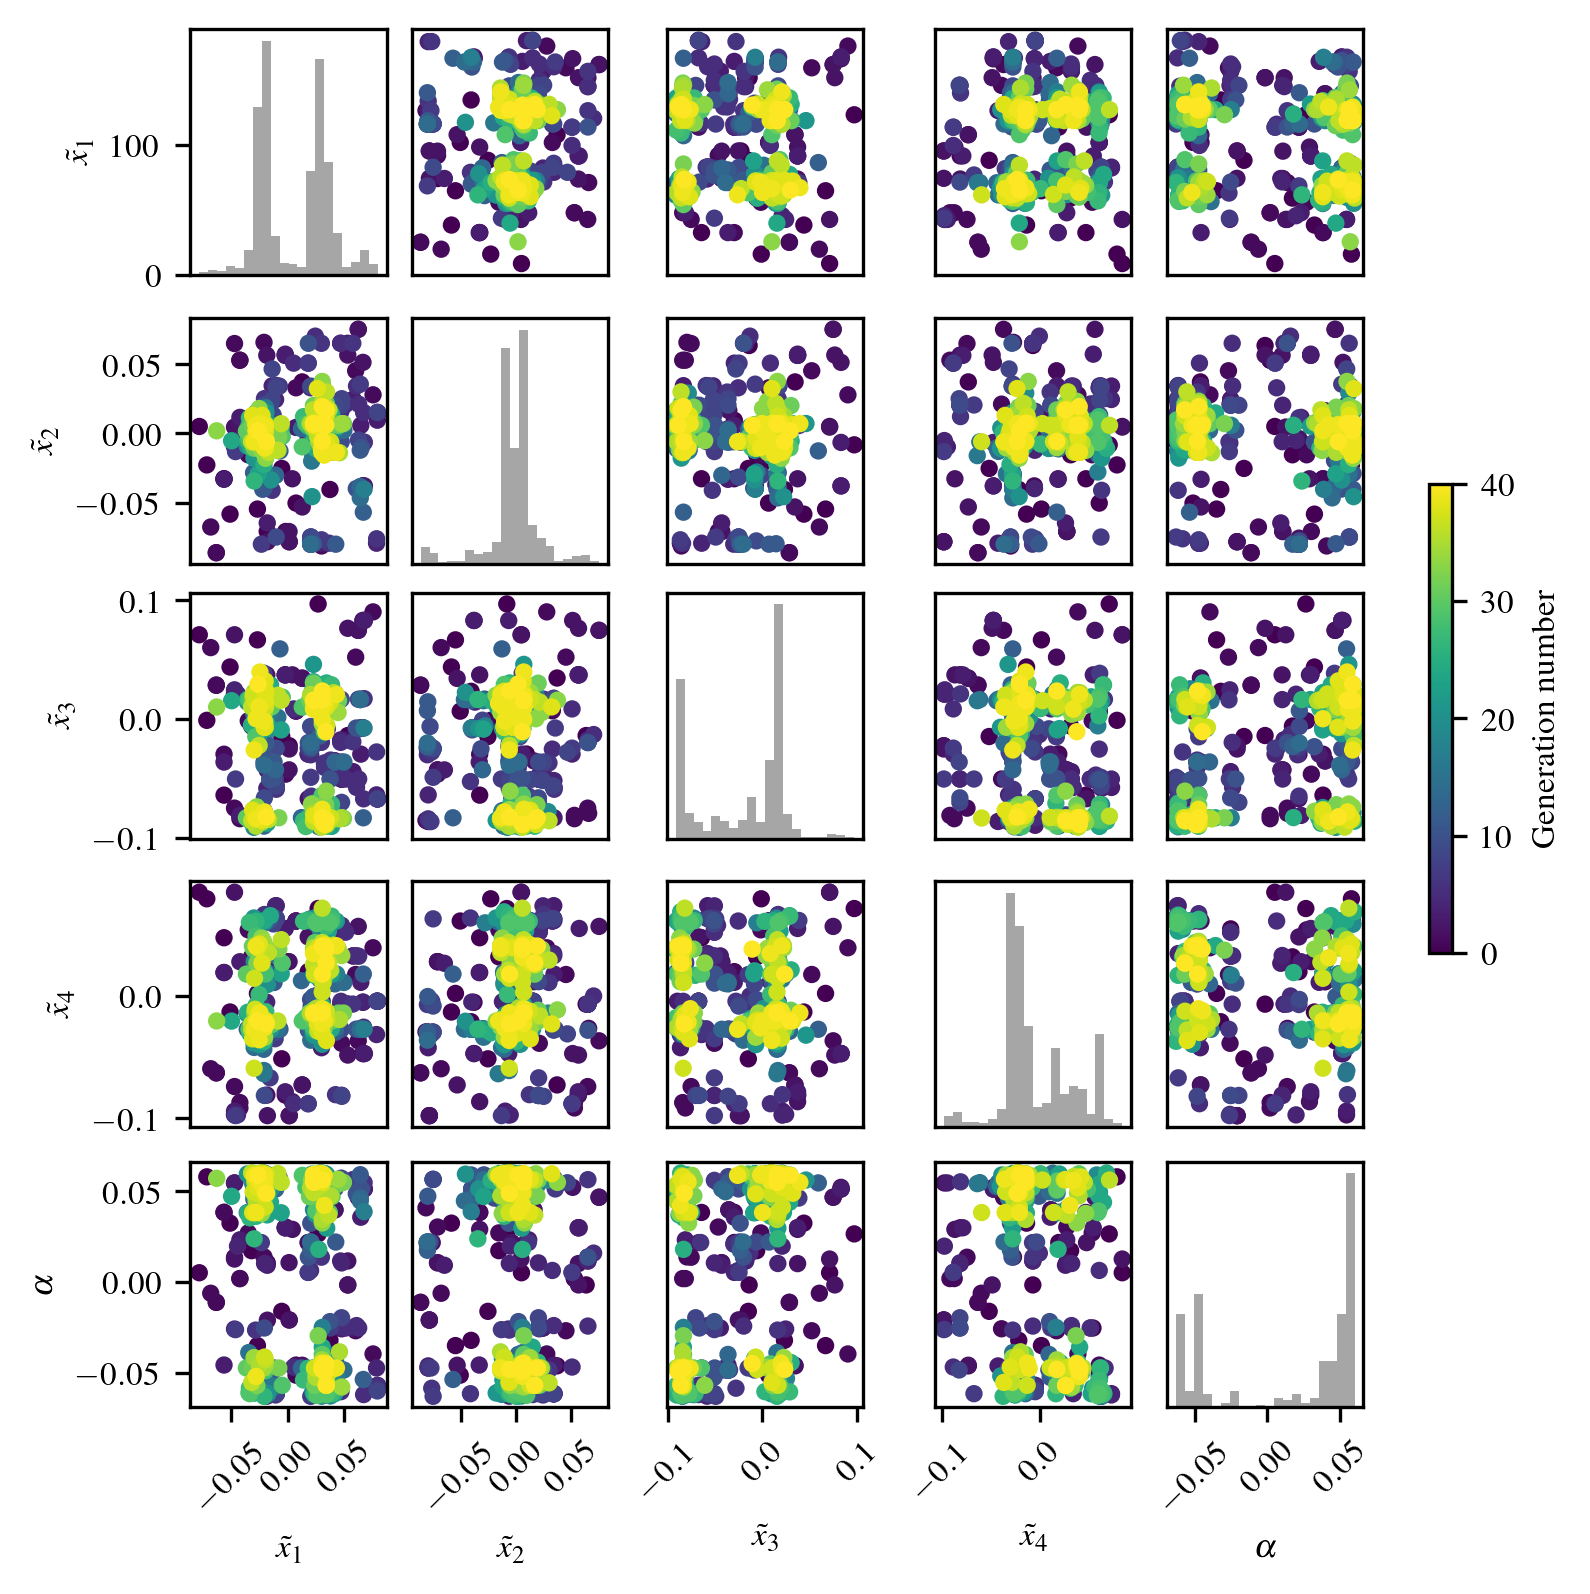

In [ ]:
fig, axes = plt.subplots(n_features, n_features, figsize=(5.2, 5.2), constrained_layout=True)
labels=['$\\tilde{x}_1$', '$\\tilde{x}_2$', '$\\tilde{x}_3$', '$\\tilde{x}_4$', '$\\tilde{x}_5$']

# Normalize row indices for colormap
cmap='viridis'
row_indices = np.arange(len(lf_fit))
norm = plt.Normalize(row_indices.min() // 20, row_indices.max() // 20)
cmap = cm.get_cmap('viridis')
colors = cmap(norm(row_indices // 20))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            ax.hist(data[:, i], bins=20, color="gray", alpha=0.7)
        else:
            ax.scatter(data[:, j], data[:, i], c=colors, s=10)
        
        if i == n_features - 1:
            ax.set_xlabel(labels[j] if labels else f"X{j}")
        else:
            ax.set_xticks([])
        if j == 0:
            ax.set_ylabel(labels[i] if labels else f"X{i}")
        else:
            ax.set_yticks([])
        ax.tick_params(axis='x', labelrotation=45)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.05)
cbar.set_label('Generation number')
plt.show()

Load NSGA-II optimal HF candidate and plot as LF

In [16]:
nsga_opt_cand = np.loadtxt("../examples/LRN-CASCADE/cascade_musicaa_base/output_nsga_opt/candidates.txt")
nsga_opt_fit = np.array([0.07463, 0.5 * (0.1787 + 0.07468)])

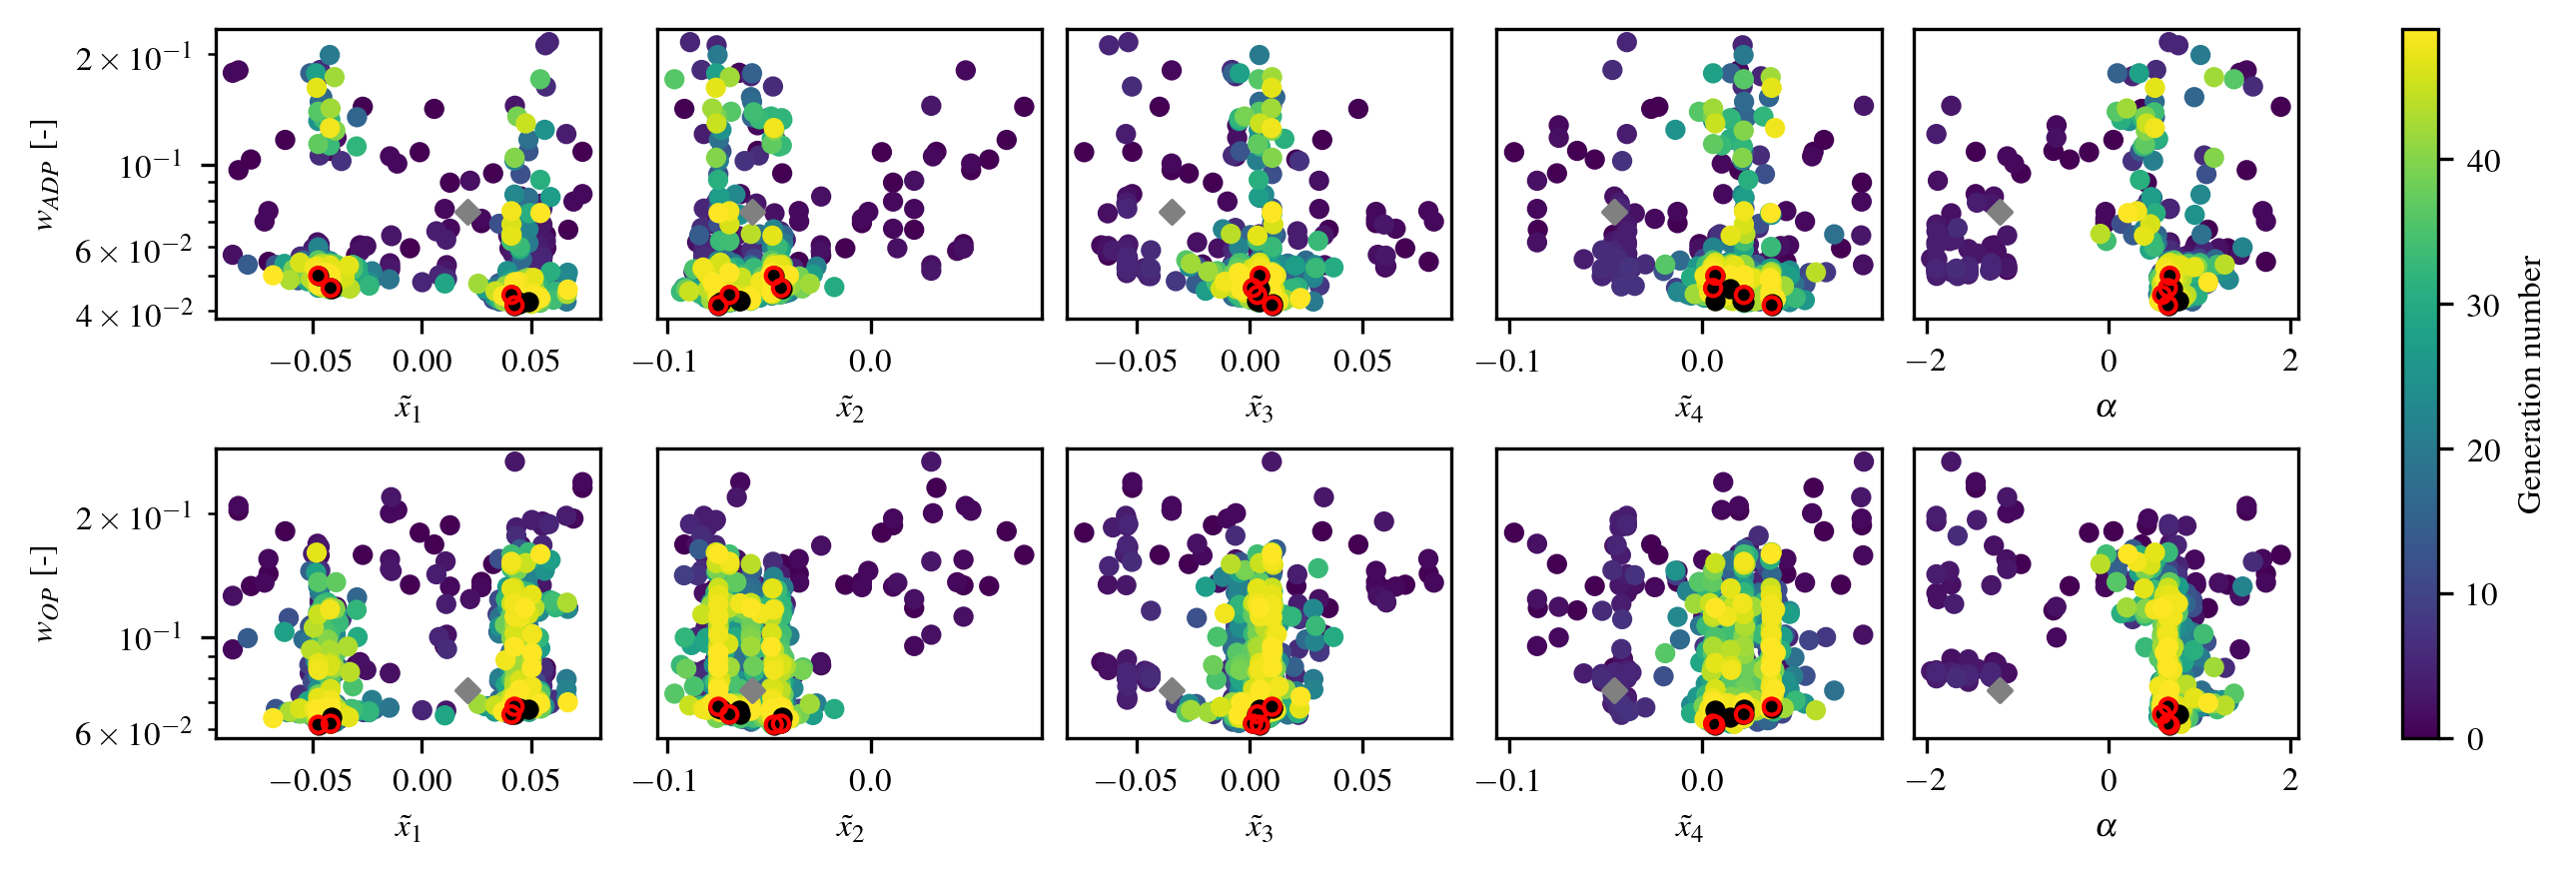

In [44]:
responses = lf_fit
optimal_candidates = [lf_cand[idx] for idx in [lf_ADP_cand_idx, lf_OP_cand_idx] + lf_cand_idx]

# Row-based colormap
row_indices = np.arange(len(lf_fit))
norm = plt.Normalize(row_indices.min() // pop_size, row_indices.max() // pop_size)
cmap = cm.get_cmap('viridis')
colors = cmap(norm(row_indices // pop_size))

# Plot
fig, axes = plt.subplots(2, n_features, figsize=(8.5, 2.8), constrained_layout=True)

for i in range(n_features):
    ax = axes[0, i]
    ax.set_yscale('log')
    if i == 0:
        ax.set_ylabel('$w_{ADP}$ [-]')
    ax.scatter(data[:, i], responses[:, 0], c=colors, s=15)
    for idx in lf_pareto_idx:
        ax.scatter(lf_cand[idx, i], lf_fit[idx, 0], color="k", s=15)
    for cand, fit in zip(optimal_candidates, lf_opt):
        ax.scatter(cand[i], fit[0], facecolors="none", edgecolors="r", s=15)
    # nsga HF optimal candidate recomputed in LF
    ax.scatter(nsga_opt_cand[i], nsga_opt_fit[0], marker="D", color="gray", s=15, zorder=100)
    ax.set_xlabel(labels[i])
    if i != 0:
        ax.yaxis.minorticks_off()
        ax.set_yticklabels([])
        ax.tick_params(left=False)
        ax.yaxis.set_major_locator(plt.NullLocator())
for i in range(n_features):
    ax = axes[1, i]
    ax.set_yscale('log')
    if i == 0:
        ax.set_ylabel('$w_{OP}$ [-]')
    ax.scatter(data[:, i], responses[:, 1], c=colors, s=15)
    for idx in lf_pareto_idx:
        ax.scatter(lf_cand[idx, i], lf_fit[idx, 1], color="k", s=15)
    for cand, fit in zip(optimal_candidates, lf_opt):
        ax.scatter(cand[i], fit[1], facecolors="none", edgecolors="r", s=15)
    # nsga HF optimal candidate recomputed in LF
    ax.scatter(nsga_opt_cand[i], nsga_opt_fit[0], marker="D", color="gray", s=15, zorder=100)
    ax.set_xlabel(labels[i])
    if i != 0:
        ax.yaxis.minorticks_off()
        ax.set_yticklabels([])
        ax.tick_params(left=False)
        ax.yaxis.set_major_locator(plt.NullLocator())

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.05)
cbar.set_label('Generation number')
plt.savefig(os.path.join(os.getcwd(), "lf_space.pdf"), bbox_inches="tight")
plt.show()

In [17]:
X_recomp

array([[0.02933745, 0.04835062],
       [0.0356293 , 0.04484933],
       [0.03052713, 0.04691087],
       [0.03327193, 0.04420507]])